# Лабораторная работа 4. Введение в PyTorch

#### Работу выполнил: Самойло Александр, студент группы ФИб-4

## Библиотека PyTorch

Библиотека `pyTorch` используется для обучения нейронных сетей. Чтобы установить библиотеку локально воспользуйтесь [руководством]("https://pytorch.org/get-started/locally/).

**(!) В среде colab библиотека `pytorch` является уже предустановленной.**

Импорт библиотеки происходит обычным образом, а вывод установленной версии `pytorch` можно сделать так

In [1]:
import torch
torch.__version__

'2.10.0+cpu'

В библиотеке `pytorch` есть поддержка вычислений на `GPU`, чтобы в colab подключить видеокарту надо в меню `Runtime` перейти в настройки `Change runtime type` и выбрать `T4 GPU`. При этом произойдёт подключение к новой сессии.
Чтобы посмотреть полезную информацию о видеокарте, можно воспользоваться утилитой `nvidia-smi`, для этого в ячейке colab можно ввести команду:
```
!nvidia-smi
```
Также можно посмотреть дополнительную информацию о системе:
```python
print('Python VERSION:', sys.version)
print('\npyTorch VERSION:', torch.__version__)
print('\nCUDA VERSION:')
! nvcc --version
print('\nCUDNN VERSION:', torch.backends.cudnn.version())
print('\nNumber CUDA Devices:', torch.cuda.device_count())
print('Current cuda device:', torch.cuda.current_device())
print('Cuda device name: ', torch.cuda.get_device_name(0))
```

А проверить доступность видеокарты через `pytorch` можно так:
```python
torch.cuda.is_available()
```

**(!) Для выполнения текущей лабораторной работы видеокарта не нужна.**

### Знакомство с тензорами

Основными строительными блоками в pytorch являются тензоры. Каждый тензор представляет многомерную матрицу. Например, цветное изображение размера `256x256` пикселей можно представить как тензор размерности `3x256x256`.

Создание тензоров происходит следующим образом:

In [2]:
list_of_lists = [
  [1, 2, 3],
  [4, 5, 6],
]
print(f"Исходные данные: {list_of_lists}")

data = torch.tensor(list_of_lists)
print(f"Тензор: {data}")

Исходные данные: [[1, 2, 3], [4, 5, 6]]
Тензор: tensor([[1, 2, 3],
        [4, 5, 6]])


In [3]:
data = torch.tensor([
                     [0, 1],
                     [2, 3],
                     [4, 5]
                    ])
print(f"Тензор: {data}")

Тензор: tensor([[0, 1],
        [2, 3],
        [4, 5]])


Каждый тензор имеет тип данных (data type): основные типы данных — это числа с плавающей запятой (`torch.float32`) и целые числа (`torch.int`). При создании тензора можно явно указать тип данных:

In [4]:
data = torch.tensor([
                     [0, 1],
                     [2, 3],
                     [4, 5]
                    ], dtype=torch.float32)
print(f"Тензор: {data}")

Тензор: tensor([[0., 1.],
        [2., 3.],
        [4., 5.]])


In [5]:
data = torch.tensor([
                     [0.11111111, 1],
                     [2, 3],
                     [4, 5]
                    ], dtype=torch.int)
print(f"Тензор: {data}")

Тензор: tensor([[0, 1],
        [2, 3],
        [4, 5]], dtype=torch.int32)


In [6]:
data = torch.tensor([
                     [0.11111111, 1],
                     [2, 3],
                     [4, 5]
                    ])
print(f"Тензор: {data}")

Тензор: tensor([[0.1111, 1.0000],
        [2.0000, 3.0000],
        [4.0000, 5.0000]])


Также существуют служебные функции для создания тензоров заданной формы и заданным содержимым:

In [7]:
#Тензор нулей
zeros = torch.zeros(2, 5)
print(zeros)

tensor([[0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.]])


In [8]:
#Тензор единиц
ones = torch.ones(3, 4)
print(ones)

tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]])


In [9]:
#Тензор целых чисел из диапазона от 1 до 10
rr = torch.arange(1, 10) # range from [1, 10)
print(rr)

tensor([1, 2, 3, 4, 5, 6, 7, 8, 9])


Примеры простых операций с тензорами

In [10]:
rr + 2

tensor([ 3,  4,  5,  6,  7,  8,  9, 10, 11])

In [11]:
rr * 2

tensor([ 2,  4,  6,  8, 10, 12, 14, 16, 18])

In [12]:
a = torch.tensor([[1, 2], [2, 3], [4, 5]])      # (3, 2)
b = torch.tensor([[1, 2, 3, 4], [5, 6, 7, 8]])  # (2, 4)

print(f"A: {a}")
print(f"B: {b}")
print(f"A*B: {a.matmul(b)}")
print(f"Другие операции (+, -, *, @): {a @ b}")
print(f"Другие операции (+, -, *, @): {a - a}")

A: tensor([[1, 2],
        [2, 3],
        [4, 5]])
B: tensor([[1, 2, 3, 4],
        [5, 6, 7, 8]])
A*B: tensor([[11, 14, 17, 20],
        [17, 22, 27, 32],
        [29, 38, 47, 56]])
Другие операции (+, -, *, @): tensor([[11, 14, 17, 20],
        [17, 22, 27, 32],
        [29, 38, 47, 56]])
Другие операции (+, -, *, @): tensor([[0, 0],
        [0, 0],
        [0, 0]])


Размерность (форма) тензора можно узнать через поле `.shape`.

Некоторые примеры:

In [13]:
matr_2d = torch.tensor([[1, 2, 3], [4, 5, 6]])
print(matr_2d.shape)
print(matr_2d)

torch.Size([2, 3])
tensor([[1, 2, 3],
        [4, 5, 6]])


In [14]:
matr_3d = torch.tensor([[[1, 2, 3, 4], [-2, 5, 6, 9]], [[5, 6, 7, 2], [8, 9, 10, 4]], [[-3, 2, 2, 1], [4, 6, 5, 9]]])
print(matr_3d)
print(matr_3d.shape)

tensor([[[ 1,  2,  3,  4],
         [-2,  5,  6,  9]],

        [[ 5,  6,  7,  2],
         [ 8,  9, 10,  4]],

        [[-3,  2,  2,  1],
         [ 4,  6,  5,  9]]])
torch.Size([3, 2, 4])


Также можно изменять размерность уже созданного тензора:

In [15]:
rr = torch.arange(1, 16)
print("Размерность", rr.shape)
print("Значение", rr)
print()
rr = rr.view(5, 3)
print("После изменения формы (reshaping), размерность", rr.shape)
print("Значение", rr)

Размерность torch.Size([15])
Значение tensor([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15])

После изменения формы (reshaping), размерность torch.Size([5, 3])
Значение tensor([[ 1,  2,  3],
        [ 4,  5,  6],
        [ 7,  8,  9],
        [10, 11, 12],
        [13, 14, 15]])


Также тензоры можно конвертировать в numpy-массивы

In [16]:
import numpy as np

# numpy.ndarray --> torch.Tensor:
arr = np.array([[1, 0, 5]])
data = torch.tensor(arr)
print(f"torch.tensor {data}")

# torch.Tensor --> numpy.ndarray:
new_arr = data.numpy()
print(f"np.ndarray {new_arr}")

torch.tensor tensor([[1, 0, 5]])
np.ndarray [[1 0 5]]


Одна из причин, по которой удобно использовать тензоры, заключается в векторизованных операциях. Данные операции обрабатываются быстрее, так как выполняются параллельно.

In [17]:
data = torch.arange(1, 36, dtype=torch.float32).reshape(5, 7)
print(f"Данные {data}")

# Суммирование строк
print("Taking the sum over rows:")
print(data.sum(dim=1))

# Суммирование столбцов
print("Taking thep sum over columns:")
print(data.sum(dim=0))

# Вычисление стандартного отклонения
print("Taking the stdev over rows:")
print(data.std(dim=1))

Данные tensor([[ 1.,  2.,  3.,  4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11., 12., 13., 14.],
        [15., 16., 17., 18., 19., 20., 21.],
        [22., 23., 24., 25., 26., 27., 28.],
        [29., 30., 31., 32., 33., 34., 35.]])
Taking the sum over rows:
tensor([ 28.,  77., 126., 175., 224.])
Taking thep sum over columns:
tensor([ 75.,  80.,  85.,  90.,  95., 100., 105.])
Taking the stdev over rows:
tensor([2.1602, 2.1602, 2.1602, 2.1602, 2.1602])


In [18]:
data = torch.arange(1, 7, dtype=torch.float32).reshape(1, 2, 3)
print(data)
print(data.sum(dim=0).sum(dim=0))
print(data.sum(dim=0).sum(dim=0).shape)

tensor([[[1., 2., 3.],
         [4., 5., 6.]]])
tensor([5., 7., 9.])
torch.Size([3])


In [19]:
data.sum()

tensor(21.)

Доступ к элементам тензора производится через оператор `[]`. Поддерживается операция слайсинга.

In [20]:
x = torch.Tensor([
                  [[1, 2], [3, 4]],
                  [[5, 6], [7, 8]],
                  [[9, 10], [11, 12]]
                 ])
print(f"{x}")
print(f"{x.shape}")
print(f"{x[0]}")
print(f"{x[:, 0]}")
print(f"{x[:, 0, 0]}")

tensor([[[ 1.,  2.],
         [ 3.,  4.]],

        [[ 5.,  6.],
         [ 7.,  8.]],

        [[ 9., 10.],
         [11., 12.]]])
torch.Size([3, 2, 2])
tensor([[1., 2.],
        [3., 4.]])
tensor([[ 1.,  2.],
        [ 5.,  6.],
        [ 9., 10.]])
tensor([1., 5., 9.])


In [21]:
print(f"{x[:,:,:]}")
i = torch.tensor([0, 0, 1, 1])
print(f"{x[i]}")

tensor([[[ 1.,  2.],
         [ 3.,  4.]],

        [[ 5.,  6.],
         [ 7.,  8.]],

        [[ 9., 10.],
         [11., 12.]]])
tensor([[[1., 2.],
         [3., 4.]],

        [[1., 2.],
         [3., 4.]],

        [[5., 6.],
         [7., 8.]],

        [[5., 6.],
         [7., 8.]]])


### Autograd

Библиотека `pytorch` известена возможностью автоматического дифференцирования. Используя метод `backward()`, можно вычислить градиенты, которые сохраняются в атрибуте `grad`.

In [22]:
x = torch.tensor([2.], requires_grad=True)

print(x.grad)

None


In [23]:
#requires_grad=True, значит, что все операции с тензором запоминаются
#None так как производной не существует

In [24]:
y = x * x * 3 # 3x^2
y.backward()
print(x.grad) # d(y)/d(x) = d(3x^2)/d(x) = 6x = 12

tensor([12.])


In [25]:
'''
задали функцию и запустили обратное распространение, находим производную
6x и подставляем туда 2
Теперь число 12 хранится в атрибуте grad тензора x. 
На это число нейросеть будет свдигать веса, чтобы минимизировать функцию потерь.
'''

'\nзадали функцию и запустили обратное распространение, находим производную\n6x и подставляем туда 2\nТеперь число 12 хранится в атрибуте grad тензора x. \nНа это число нейросеть будет свдигать веса, чтобы минимизировать функцию потерь.\n'

### Модуль нейронной сети

Импортировать модуль для работы с нейронными сетями в библиотеки `pytorch` можно следующим образом:

In [26]:
import torch.nn as nn

Для создания линейного слоя используется `nn.Linear(H_in, H_out)`. Входом линейного слоя будет матрица размерностью `(N, *, H_in)` и выходом будет матрица размерностью `(N, *, H_out)`. Символ `*` означает, что между ними может быть произвольное количество измерений.

Линейный уровень выполняет преобразование `Ax+b`, где `A` и `b` инициализируются случайным образом. Если нужно, чтобы в линейном слое не было параметров смещения, то можно инициализировать слой с аргументом `bias= False`.

In [27]:
input = torch.ones(2,3,4)
# N* H_in -> N*H_out

# dimensional outputs
linear = nn.Linear(4, 2)
linear_output = linear(input)
linear_output

tensor([[[-0.1914,  0.1890],
         [-0.1914,  0.1890],
         [-0.1914,  0.1890]],

        [[-0.1914,  0.1890],
         [-0.1914,  0.1890],
         [-0.1914,  0.1890]]], grad_fn=<ViewBackward0>)

In [28]:
'''
2 таблицы 3 строки и 4 столбца заполненных 1
Создали линейный слой, где на вход 4 числа, на выход 2
пропуск единиц через слой, каждая четверка единиц превратилась в пару чисел,
слой переработал  4 признака в 2
'''

'\n2 таблицы 3 строки и 4 столбца заполненных 1\nСоздали линейный слой, где на вход 4 числа, на выход 2\nпропуск единиц через слой, каждая четверка единиц превратилась в пару чисел,\nслой переработал  4 признака в 2\n'

In [29]:
linear_output.shape

torch.Size([2, 3, 2])

In [30]:
list(linear.parameters()) # Ax + b

[Parameter containing:
 tensor([[ 0.1788, -0.4588,  0.2763,  0.1928],
         [-0.3713,  0.1640,  0.3395,  0.3916]], requires_grad=True),
 Parameter containing:
 tensor([-0.3806, -0.3348], requires_grad=True)]

In [31]:
list(linear.named_parameters()) # параметры с обозначениями

[('weight',
  Parameter containing:
  tensor([[ 0.1788, -0.4588,  0.2763,  0.1928],
          [-0.3713,  0.1640,  0.3395,  0.3916]], requires_grad=True)),
 ('bias',
  Parameter containing:
  tensor([-0.3806, -0.3348], requires_grad=True))]

In [32]:
'''
Weight (Веса): Матрица размером 2 на 4
Это те самые коэффициенты, на которые умножаются входные данные.
Bias (Смещение): Вектор из 2 чисел. 
Это константа, которая прибавляется в конце.
'''

'\nWeight (Веса): Матрица размером 2 на 4\nЭто те самые коэффициенты, на которые умножаются входные данные.\nBias (Смещение): Вектор из 2 чисел. \nЭто константа, которая прибавляется в конце.\n'

В модуле `nn` есть и другие предварительно настроенные слои. Примеры других слоёв: `nn.Conv2d`, `nn.ConvTranspose2d`, `nn.BatchNorm1d`, `nn.BatchNorm2d`, `nn.Upsample` и `nn.MaxPool2d` и многие другие.

Также можно использовать модуль `nn` для применения функций активации к тензорам. Функции активации используются для добавления нелинейности в нейронную сеть. Примерами функций активации являются `nn.ReLU()`, `nn.Sigmoid()` и `nn.LeakyReLU()`. Функции активации работают с каждым элементом отдельно, поэтому размерность тензоров, которые получаем на выходе, такая же, как и у тензоров, которые передаём.

In [33]:
linear_output

tensor([[[-0.1914,  0.1890],
         [-0.1914,  0.1890],
         [-0.1914,  0.1890]],

        [[-0.1914,  0.1890],
         [-0.1914,  0.1890],
         [-0.1914,  0.1890]]], grad_fn=<ViewBackward0>)

In [34]:
sigmoid = nn.Sigmoid()
output = sigmoid(linear_output)
output

tensor([[[0.4523, 0.5471],
         [0.4523, 0.5471],
         [0.4523, 0.5471]],

        [[0.4523, 0.5471],
         [0.4523, 0.5471],
         [0.4523, 0.5471]]], grad_fn=<SigmoidBackward0>)

In [35]:
'''
Здесь мы создали слой nn.Linear, 
который принимает на вход вектор из 4 чисел и выдаёт вектор из 2 чисел.
Затем мы применили функцию активации Sigmoid, 
которая сжимает выходные значения в диапазон от 0 до 1.
Превращаем сырые числа в вероятности, которые можно интерпретировать
как уверенность модели в том, что входные данные принадлежат к определённому классу.

Если на входе 0 -> на выходе 0.5
Если на входе большое число -> на выходе 1
Если на входе маленькое число -> на выходе 0
'''

'\nЗдесь мы создали слой nn.Linear, \nкоторый принимает на вход вектор из 4 чисел и выдаёт вектор из 2 чисел.\nЗатем мы применили функцию активации Sigmoid, \nкоторая сжимает выходные значения в диапазон от 0 до 1.\nПревращаем сырые числа в вероятности, которые можно интерпретировать\nкак уверенность модели в том, что входные данные принадлежат к определённому классу.\n\nЕсли на входе 0 -> на выходе 0.5\nЕсли на входе большое число -> на выходе 1\nЕсли на входе маленькое число -> на выходе 0\n'

Чтобы объединять преобразования можно использовать `nn.Sequentual`. Для вывода парааметров можно использовать функции `parameters()` и `names_parameters()`

In [36]:
block = nn.Sequential(
    nn.Linear(4, 2),
    nn.Sigmoid()
)

input = torch.ones(2,3,4)
print(f"Входной тензор: {input}")
print(f"Параметры линейного слоя: {list(linear.named_parameters())}")
output = block(input)
print(f"Выходной тензор: {output}")

Входной тензор: tensor([[[1., 1., 1., 1.],
         [1., 1., 1., 1.],
         [1., 1., 1., 1.]],

        [[1., 1., 1., 1.],
         [1., 1., 1., 1.],
         [1., 1., 1., 1.]]])
Параметры линейного слоя: [('weight', Parameter containing:
tensor([[ 0.1788, -0.4588,  0.2763,  0.1928],
        [-0.3713,  0.1640,  0.3395,  0.3916]], requires_grad=True)), ('bias', Parameter containing:
tensor([-0.3806, -0.3348], requires_grad=True))]
Выходной тензор: tensor([[[0.4665, 0.4294],
         [0.4665, 0.4294],
         [0.4665, 0.4294]],

        [[0.4665, 0.4294],
         [0.4665, 0.4294],
         [0.4665, 0.4294]]], grad_fn=<SigmoidBackward0>)


In [37]:
'''
все данные проходят через линейный слой, который умножает их на веса и прибавляет смещение,
затем результат проходит через функцию активации Sigmoid, которая сжимает выходные значения в диапазон от 0 до 1.

после чего в блок мы подаем на вход единицы,а потом получаем сразу готовый результат

Нейросеть из одного нейрона, одного полносвязаного слоя, где:

linear - тело нейрона, которое делает вычисления
sigmoid - функция активации, которая говорит насколько сильный сигнал от нейрона на выходе
sequential - блок, который объединяет эти два элемента в единое целое
'''

'\nвсе данные проходят через линейный слой, который умножает их на веса и прибавляет смещение,\nзатем результат проходит через функцию активации Sigmoid, которая сжимает выходные значения в диапазон от 0 до 1.\n\nпосле чего в блок мы подаем на вход единицы,а потом получаем сразу готовый результат\n\nНейросеть из одного нейрона, одного полносвязаного слоя, где:\n\nlinear - тело нейрона, которое делает вычисления\nsigmoid - функция активации, которая говорит насколько сильный сигнал от нейрона на выходе\nsequential - блок, который объединяет эти два элемента в единое целое\n'

**Задание 1.** Нарисуйте нейронную сеть, которая соответствует `block` (примеру выше). Ответьте на следующие вопросы:
- Сколько нейронов имеет нейронная сеть?
- Сколько обучаемых весов содержит нейронная сеть?
- Что является выходом нейронной сети?

In [38]:
'''
В полносвязном слое nn.Linear(4, 2) есть 4 входных признака и 2 выходных признака.
out_features - это количество выходных признаков, которые выдаёт слой = 2 нейрона.

10 параметров, так как 4 входа на 2 нейрона = 8 весов
+ 2 смещения(biases) (по одному на каждый нейрон) = 10 параметров.

Выходом нейронной сети является вектор из двух чисел в диапозоне от 0 до 1.

'''

'\nВ полносвязном слое nn.Linear(4, 2) есть 4 входных признака и 2 выходных признака.\nout_features - это количество выходных признаков, которые выдаёт слой = 2 нейрона.\n\n10 параметров, так как 4 входа на 2 нейрона = 8 весов\n+ 2 смещения(biases) (по одному на каждый нейрон) = 10 параметров.\n\nВыходом нейронной сети является вектор из двух чисел в диапозоне от 0 до 1.\n\n'

Можно создавать собственные слои и блоки нейронных сетей. Для этого нужно создать класс, наследуемый от `nn.Module`. В функции `__init__` проинициализировать параметры сети. А в методе `forward` определить прямой проход по слоям сети.

Чтобы код ниже был понятным вспомните про основы ООП в языке python - например, прочитайте [статью](https://education.yandex.ru/handbook/python/article/obuektnaya-model-python-klassy-polya-i-metody).

In [39]:
class MultilayerPerceptron(nn.Module):

  def __init__(self, input_size, hidden_size):
    # Вызываем инициализацию родителя
    super(MultilayerPerceptron, self).__init__()

    self.input_size = input_size
    self.hidden_size = hidden_size

    # Defining of our model
    # There isn't anything specific about the naming of `self.model`. It could
    # be something arbitrary.
    self.model = nn.Sequential(
        nn.Linear(self.input_size, self.hidden_size), # 1 слой. Сжимает и расширяет данные
        nn.ReLU(), # функция активации. все отриц. числа в 0 остальные как есть
        nn.Linear(self.hidden_size, self.input_size), #2 слой, возвращает данные к исходному размеру
        nn.Sigmoid() #финальное сжатие в диапазон от 0 до 1
    )

  def forward(self, x):
    output = self.model(x)
    return output

In [40]:
'''
Быстрый способ, 
упаковываем слои в одну коробку self.model, когда приходят данные в forward, то 
они проходят через всю коробку целиком.
'''

'\nБыстрый способ, \nупаковываем слои в одну коробку self.model, когда приходят данные в forward, то \nони проходят через всю коробку целиком.\n'

Пример выше, может быть оформлен без использования `nn.Sequential `.



In [41]:
class MultilayerPerceptron(nn.Module):

  def __init__(self, input_size, hidden_size):
    # Call to the __init__ function of the super class
    super(MultilayerPerceptron, self).__init__()

    # Bookkeeping: Saving the initialization parameters
    self.input_size = input_size
    self.hidden_size = hidden_size

    # Defining of our layers
    self.linear = nn.Linear(self.input_size, self.hidden_size)
    self.relu = nn.ReLU()
    self.linear2 = nn.Linear(self.hidden_size, self.input_size)
    self.sigmoid = nn.Sigmoid()

  def forward(self, x):
    linear = self.linear(x)
    relu = self.relu(linear)
    linear2 = self.linear2(relu)
    output = self.sigmoid(linear2)
    return output

In [42]:
'''
Гибкий способ. Объявляем каждый слой отдельно, а в forward описываем, 
как данные проходят через эти слои.

Полезно в тех случаях, когда нам нужно более 
сложное взаимодействие между слоями, например, когда выход одного слоя 
нужно использовать в нескольких местах
'''

'\nГибкий способ. Объявляем каждый слой отдельно, а в forward описываем, \nкак данные проходят через эти слои.\n\nПолезно в тех случаях, когда нам нужно более \nсложное взаимодействие между слоями, например, когда выход одного слоя \nнужно использовать в нескольких местах\n'

После определения класса нейронной сети можно создать его экземпляр, а затем использовать для предсказаний и обучения.

In [43]:
input = torch.randn(2, 5)
print(f"Входные данные: {input}")

model = MultilayerPerceptron(5, 3)
print(f"Параметры сети: {list(model.named_parameters())}")

output = model(input)
print(f"Выход сети: {output}")

Входные данные: tensor([[-0.2564, -0.8184,  2.5684, -0.9898,  0.6956],
        [-0.4115,  0.8444, -2.4932, -1.3625, -0.5045]])
Параметры сети: [('linear.weight', Parameter containing:
tensor([[ 0.1081, -0.2769, -0.2227, -0.0683,  0.4355],
        [ 0.3120, -0.1118, -0.2893,  0.2425, -0.0981],
        [ 0.2694, -0.3412,  0.2506, -0.1675, -0.2930]], requires_grad=True)), ('linear.bias', Parameter containing:
tensor([ 0.0625, -0.0309,  0.3888], requires_grad=True)), ('linear2.weight', Parameter containing:
tensor([[ 0.1902, -0.5676, -0.2246],
        [ 0.1972,  0.4899, -0.3232],
        [-0.3871, -0.4445, -0.3757],
        [-0.4065,  0.1999, -0.0163],
        [ 0.4486,  0.0725,  0.1025]], requires_grad=True)), ('linear2.bias', Parameter containing:
tensor([-0.1464,  0.3566,  0.1021,  0.3984, -0.3401], requires_grad=True))]
Выход сети: tensor([[0.4000, 0.4948, 0.4077, 0.5877, 0.4527],
        [0.4472, 0.6201, 0.4842, 0.5864, 0.4425]], grad_fn=<SigmoidBackward0>)


**Задание 2.** Нарисуйте нейронную сеть (*можно на листе бумаги или в любом редакторе*), которая соответствует `MultilayerPerceptron` (пример выше). Ответьте на следующие вопросы:
- Сколько нейронов имеет нейронная сеть?
- Сколько обучаемых весов содержит нейронная сеть?
- Что является выходом нейронной сети?

In [44]:
'''
Нейронная сеть имеется 8 нейронов: 3 в первом слое и 5 во втором слое.

Всего 38 обучаемых параметров: 5 входов на 3 нейрона = 15 весов + 3 смещения в первом слое = 18 параметров
3 нейрона на 5 нейронов = 15 весов + 5 смещений во втором слое = 20 параметров
Итого: 18 + 20 = 38 параметров.

Выход нейронной сети - это вектор из 5 чисел в диапазоне от 0 до 1, 
который является результатом прохождения входных данных через два слоя 
и функцию активации.

т.к. linear2 - выходной слой имеет размер input_size = 5, то на выходу всегда ровно 5 чисел
В такой архитектуре выход часто интерпретируется как попытка сети восстановить входные данные 
или предсказать вероятности для 5 различных признаков.
'''

'\nНейронная сеть имеется 8 нейронов: 3 в первом слое и 5 во втором слое.\n\nВсего 38 обучаемых параметров: 5 входов на 3 нейрона = 15 весов + 3 смещения в первом слое = 18 параметров\n3 нейрона на 5 нейронов = 15 весов + 5 смещений во втором слое = 20 параметров\nИтого: 18 + 20 = 38 параметров.\n\nВыход нейронной сети - это вектор из 5 чисел в диапазоне от 0 до 1, \nкоторый является результатом прохождения входных данных через два слоя \nи функцию активации.\n\nт.к. linear2 - выходной слой имеет размер input_size = 5, то на выходу всегда ровно 5 чисел\nВ такой архитектуре выход часто интерпретируется как попытка сети восстановить входные данные \nили предсказать вероятности для 5 различных признаков.\n'

В процессе обучения нейронной сети кроме вычисления градиентов, что можно сделать с помощью метода `backward()`, требуется выполнять обновление весов посредством оптимизатора. Модуль `torch.optim` содержит нескоторые оптимизаторы, наиболее популярные из которых — `optim.SGD` и `optim.Adam`. При инициализации оптимизаторов передаются параметры модели, доступ к которым можно получить с помощью `model.parameters()`. У оптимизаторов также есть параметр скорости обучения (`lr`), который определяет, насколько большое обновление будет производиться на каждом этапе. Разные оптимизаторы также имеют разные гиперпараметры.

In [45]:
import torch.optim as optim

Также для обучения требуется определить функцию потерь, например, это может быть одна из реализаций бинарной кросс-энтропии `nn.BCELoss()`.

In [46]:
# Пусть есть некоторые данные
y = torch.ones(10, 5)

# Добавим шум в эти данные и попробуем предсказать исходные данные, используя обученную нейронную сеть
x = y + torch.randn_like(y)

In [47]:
# Инициализируем модель
model = MultilayerPerceptron(5, 3)

# Определяем оптимизатор
adam = optim.Adam(model.parameters(), lr=1e-1) # 2ой аргумент - скорость исправлеия ошибок учителем

# Определяем функцию потерь
loss_function = nn.BCELoss()

# Вычисляем предсказания модели на зашумленных данных и считаем ошибку предсказания
y_pred = model(x)
print(y_pred)
loss_function(y_pred, y).item()

tensor([[0.5960, 0.5418, 0.6621, 0.3761, 0.3803],
        [0.6253, 0.5692, 0.6532, 0.3526, 0.4355],
        [0.5487, 0.6691, 0.6258, 0.3596, 0.5301],
        [0.5140, 0.5819, 0.6120, 0.4216, 0.4453],
        [0.3412, 0.5849, 0.5634, 0.5357, 0.4182],
        [0.4358, 0.5263, 0.5599, 0.5082, 0.4255],
        [0.3718, 0.5861, 0.6054, 0.5012, 0.3784],
        [0.5971, 0.5487, 0.6442, 0.3794, 0.4140],
        [0.5679, 0.5433, 0.6206, 0.4062, 0.4277],
        [0.4089, 0.5662, 0.5825, 0.4973, 0.4143]], grad_fn=<SigmoidBackward0>)


0.6933139562606812

Обучим модель и вычислим ошибку уже для новых предсказаний

In [48]:
n_epoch = 10

for epoch in range(n_epoch):
  # Установим градиенты в 0 -> начинаем с чистого листа
  adam.zero_grad()

  # Получаем предсказания модели
  y_pred = model(x)

  # Вычисляем значения функции потерь на предсказаниях (сравниваем догадку с идеалом)
  loss = loss_function(y_pred, y)

  # Выводим статистику
  print(f"Epoch {epoch}: traing loss: {loss}")

  # Вычисляем градиенты
  loss.backward()

  # Обновляем параметры, делая шаг оптимизатора
  adam.step()


Epoch 0: traing loss: 0.6933139562606812
Epoch 1: traing loss: 0.48126116394996643
Epoch 2: traing loss: 0.299485981464386
Epoch 3: traing loss: 0.16717946529388428
Epoch 4: traing loss: 0.08259044587612152
Epoch 5: traing loss: 0.034745246171951294
Epoch 6: traing loss: 0.012976426631212234
Epoch 7: traing loss: 0.004710119217634201
Epoch 8: traing loss: 0.0017734962748363614
Epoch 9: traing loss: 0.0007129534496925771


Посмотрим на параметры модели. И посмотрим на предсказания модели.

In [49]:
print(list(model.parameters()))
y_pred = model(x)
print(y_pred)

[Parameter containing:
tensor([[ 0.4088, -0.6249,  0.0423, -0.2170,  0.0603],
        [ 0.6968,  1.2809,  0.6155,  1.0671,  0.7928],
        [ 0.9869,  0.6378,  1.0702,  0.3373,  0.9704]], requires_grad=True), Parameter containing:
tensor([0.2807, 1.2422, 0.8224], requires_grad=True), Parameter containing:
tensor([[0.6919, 0.5060, 1.3499],
        [0.5323, 1.2201, 1.1087],
        [0.8595, 0.9569, 0.9760],
        [0.3801, 0.7570, 0.3376],
        [0.1624, 0.8067, 1.1618]], requires_grad=True), Parameter containing:
tensor([0.3600, 0.4019, 0.6990, 1.1528, 0.3519], requires_grad=True)]
tensor([[1.0000, 1.0000, 1.0000, 0.9990, 1.0000],
        [1.0000, 1.0000, 1.0000, 0.9998, 1.0000],
        [1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
        [0.9999, 1.0000, 1.0000, 0.9986, 1.0000],
        [1.0000, 1.0000, 1.0000, 0.9999, 1.0000],
        [0.9984, 0.9998, 0.9993, 0.9933, 0.9990],
        [1.0000, 1.0000, 1.0000, 0.9999, 1.0000],
        [1.0000, 1.0000, 1.0000, 0.9993, 1.0000],
        

Сгенерируем тестовые данные, которые модели не видела в процессе обучения, и проверим предсказания.

In [50]:
x2 = y + torch.randn_like(y)
y_pred = model(x2)
y_pred

tensor([[1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
        [0.9999, 1.0000, 1.0000, 0.9993, 1.0000],
        [1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000, 0.9999, 1.0000],
        [1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000, 0.9999, 1.0000],
        [1.0000, 1.0000, 1.0000, 0.9998, 1.0000],
        [1.0000, 1.0000, 1.0000, 0.9988, 1.0000],
        [1.0000, 1.0000, 1.0000, 0.9997, 1.0000],
        [1.0000, 1.0000, 1.0000, 0.9994, 1.0000]], grad_fn=<SigmoidBackward0>)

Чтобы переместить веса нейронной сети на `GPU` можно воспользоваться методом `.to()`:
```python
model.to(device)
```
**(!) Важно, что при любых вычислениях модель и данные должны находитья на одном устройстве, поэтому при экспериментах на видеокарте не забудьте перенести входные тензоры также на видеокарту.**

## Линейная регрессия в PyTorch

#### Создание модели
Построим однослойную сеть, состоящую из одного нейрона, которая аналогична обычной линейной регрессии.

Пространство имен `nn` в PyTorch предоставляет все необходимые блоки для построения нейронных сетей.  
Каждый модуль наследует классу [nn.Module](https://pytorch.org/docs/stable/generated/torch.nn.Module.html). Нейронная сеть представляет собой также модуль, который содержит другие модули (слои).

In [51]:
from torch import nn

Определим устройство, на котором будем обучать сеть:

In [52]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Using "{}" device'.format(device))

Using "cpu" device


Опишем класс нашей нейронной сети (который должен являться наследником `nn.Module`):

In [53]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super(NeuralNetwork, self).__init__()
        self.regr = nn.Linear(1, 1) #единственный слой сети

    def forward(self, x):
        y = self.regr(x)
        return y

Метод `__init__` является конструктором класса.  
В первой строке конструктора вызывается конструктор базового класса `nn.Module`.  
Во второй строке создается единственный слой, содержащий один нейрон, с помощью модуля [Linear](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html).  
Данный модуль осуществляет линейное преобразование входа $\vec{x}$ в выход $\vec{y}$ с учетом матрицы весов $W$:  

$$\vec{y}=\vec{x}W^T+\vec{b}.$$

Первый аргумент для `Linear` – `in_features` – количество входов $x$, второй `out_features` – количество выходов $y$ (фактически, количество нейронов в данном слое). Существует также третий аргумент – `bias`, определяющий наличие вектора свободных коэффициентов $\vec{b}$ (по умолчанию `bias=True`).  
Матрица весов $W$ будет иметь размерность (`out_features`, `in_features`), вектор свободных коэффициентов $\vec{b}$ – (`out_features`).  
Значения $W$ и $\vec{b}$ инициализируются случайным образом из равномерного распределения $U(-\sqrt{k},\sqrt{k})$, где $k=\frac{1}{in\_features}$.

Заметим, что атрибут `requires_grad` для тензоров-весов сети автоматически устанавливается в `True`.

Метод `forward` определяет поток данных через нашу сеть (*прямой проход*). Аргумент `x` – это входные данные для сети. В нашем примере к `x` применяется линейное преобразование, результат которого является выходом сети (линейная регрессия).

---
Инициализируем генератор случайных чисел PyTorch для воспроизводимости результатов (для одинаковых начальных значений весов):

In [54]:
torch.manual_seed(42)

Создаем экземпляр класса `NeuralNetwork` и выводим структуру сети:

In [55]:
model = NeuralNetwork()
model

NeuralNetwork(
  (regr): Linear(in_features=1, out_features=1, bias=True)
)

---
Вывод значений весов:

In [56]:
def print_weights(model):

    for parameter in model.named_parameters():
        print(f'{parameter[0]} = {parameter[1].data}')

In [57]:
print_weights(model)

regr.weight = tensor([[0.7645]])
regr.bias = tensor([0.8300])


In [58]:
'''
Начальное значение W
началььное значение b
'''

'\nНачальное значение W\nначалььное значение b\n'

#### Генерация набора данных

Инициализируем генератор случайных чисел `numpy` для воспроизводимости результатов:

In [59]:
import numpy as np
np.random.seed(42)

Генерируем случайные данные:  
- $X$ – из равномерного распределения от 1 до 10,
- $y=2x+1$ с учетом нормально распределенного шума.

In [60]:
n_samples = 100
data = np.random.uniform(1, 10, (n_samples, 1)).astype(np.float32)
targets = 2 * data + 1 + np.random.normal(0, 2, (n_samples, 1)).astype(np.float32)

In [61]:
'''
создаем данные по формуле y=2x+1
2 - идеальный вес, который должна будет угадать модель
1 - идеальное смещение, которое должна будет угадать модель

Добавляем шум, чтобы данные были более реалистичными и сложными для модели.
np.random.normal
'''

'\nсоздаем данные по формуле y=2x+1\n2 - идеальный вес, который должна будет угадать модель\n1 - идеальное смещение, которое должна будет угадать модель\n\nДобавляем шум, чтобы данные были более реалистичными и сложными для модели.\nnp.random.normal\n'

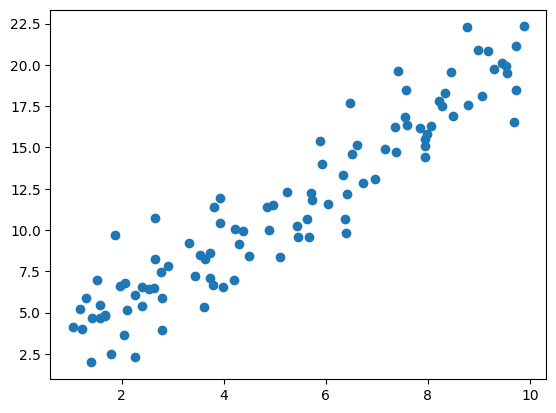

In [62]:
import matplotlib.pyplot as plt #график рассеяния
plt.scatter(data, targets) #необходим провести линию ровно через середину этого облака точек, чтобы модель могла учиться
plt.show()

Создаем тензоры PyTorch:

In [63]:
data = torch.from_numpy(data) #переупаковываем данные в тензоры
targets = torch.from_numpy(targets)

Нарисуем предсказание модели со случайно инициализированными весами:

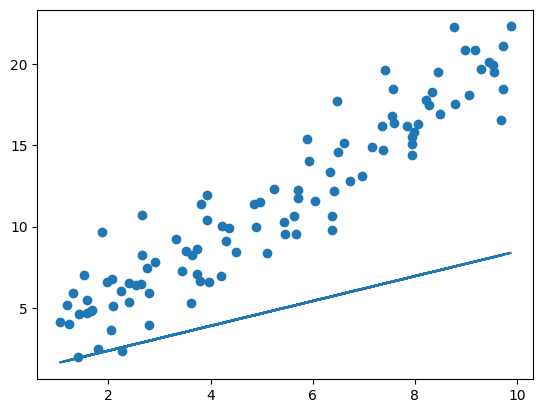

In [64]:
predictions = model(data)
plt.scatter(data.cpu().numpy(), targets.cpu().numpy())
plt.plot(data.cpu().detach().numpy(), predictions.cpu().detach().numpy())
plt.show()

In [65]:
'''
точки - реальные данные, линия - предсказания модели
Пока что модель не обучена, поэтому линия не совпадает с точками.

.cpu().detach().numpy() - чтобы matplot принимал обычный numpy, 
мы отцепляем от градиентов и переводим в numpy
'''

'\nточки - реальные данные, линия - предсказания модели\nПока что модель не обучена, поэтому линия не совпадает с точками.\n\n.cpu().detach().numpy() - чтобы matplot принимал обычный numpy, \nмы отцепляем от градиентов и переводим в numpy\n'

#### Обучение сети
Сначала задаем функцию потерь ([MSE](https://pytorch.org/docs/stable/generated/torch.nn.MSELoss.html)):

In [66]:
loss_fn = nn.MSELoss()

Затем определим оптимизатор:

In [67]:
learning_rate = 0.01
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
optimizer

SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)

Зададим функцию, определяющую действия в процессе одной эпохи обучения:

In [68]:
def train_loop(data, targets, model, loss_fn, optimizer):
    model.train()
    for i in range(len(data)): #стохастический градиентный спуск, по одной точке обновляем веса
      optimizer.zero_grad() #обнуляем градиенты, чтобы не накапливались
      pred = model(data[i])
      loss = loss_fn(pred, targets[i])#сравниваем догадку с правильным ответом
      loss.backward() #дифференцируем функцию потерь, находим градиенты
      optimizer.step() #изменение весов
      if i % 10 == 0:
        print(f'loss: {loss}')

Запускаем цикл обучения:

In [69]:
epochs = 10
print_weights(model)
for t in range(epochs):
    print(f'-------------------------------\nEpoch {t+1}')
    train_loop(data, targets, model, loss_fn, optimizer)
    print()
    print_weights(model)

regr.weight = tensor([[0.7645]])
regr.bias = tensor([0.8300])
-------------------------------
Epoch 1
loss: 32.994876861572266
loss: 3.7130351066589355
loss: 7.4773125648498535
loss: 16.94471549987793
loss: 0.06362006068229675
loss: 20.94452667236328
loss: 11.095436096191406
loss: 22.48904800415039
loss: 25.47216033935547
loss: 0.9354164004325867

regr.weight = tensor([[2.0708]])
regr.bias = tensor([1.1238])
-------------------------------
Epoch 2
loss: 0.06721831113100052
loss: 3.3904576301574707
loss: 7.715190410614014
loss: 17.0921630859375
loss: 0.09646038711071014
loss: 20.185884475708008
loss: 11.15342903137207
loss: 22.76775550842285
loss: 26.13392448425293
loss: 0.8385037779808044

regr.weight = tensor([[2.0542]])
regr.bias = tensor([1.1944])
-------------------------------
Epoch 3
loss: 0.06614460796117783
loss: 3.1809375286102295
loss: 7.878329277038574
loss: 17.192296981811523
loss: 0.12254366278648376
loss: 19.680456161499023
loss: 11.192747116088867
loss: 22.95737648010254

In [70]:
'''
Ошибка начиналась с огромного значения 32.99

ОТ эпохи к эпохе веса менялись с 0.76 до 2.07 (с 1 на 2 эпохи)
до 2.02 на последней эпохе, что уже близко к идеальному весу 2.

Смещение росло медленнее


В итоге получилась формула y=2.02x + 1.34, что уже близко к идеальной формуле y=2x+1


'''

'\nОшибка начиналась с огромного значения 32.99\n\nОТ эпохи к эпохе веса менялись с 0.76 до 2.07 (с 1 на 2 эпохи)\nдо 2.02 на последней эпохе, что уже близко к идеальному весу 2.\n\nСмещение росло медленнее\n\n\nВ итоге получилась формула y=2.02x + 1.34, что уже близко к идеальной формуле y=2x+1\n\n\n'

---
Нарисуем получившуюся модель:

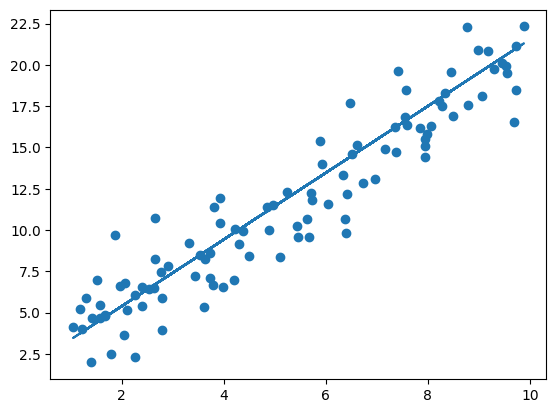

In [71]:
# Возвращаем модель в режим инференса:  эквивалентно model.training = False
model.eval()
predictions = model(data)
plt.scatter(data.cpu().numpy(), targets.cpu().numpy())
plt.plot(data.cpu().detach().numpy(), predictions.cpu().detach().numpy())

**Задание 3.** Разделите датасет на обучающую и валидационную выборки. Допишите процедуру обучения и добавьте в конце каждой эпохи вычисления loss на валидационной выборке (без изменения весов). Постройте на одном графике значения `train_loss` и `val_loss` на 10 эпохах.

In [72]:
from sklearn.model_selection import train_test_split

# Разбиваем на 80% обучение и 20% валидацию
X_train, X_val, y_train, y_val = train_test_split(
    data.numpy(), targets.numpy(), test_size=0.2, random_state=42
)

# Превращаем обратно в тензоры PyTorch
X_train = torch.from_numpy(X_train)
y_train = torch.from_numpy(y_train)
X_val = torch.from_numpy(X_val)
y_val = torch.from_numpy(y_val)

In [ ]:
def train_model(model, loss_fn, optimizer, epochs=10):
    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()
        epoch_train_loss = 0
        for i in range(len(X_train)):
            optimizer.zero_grad()
            pred = model(X_train[i])
            loss = loss_fn(pred, y_train[i])
            loss.backward()
            optimizer.step()
            epoch_train_loss += loss.item()
        
        avg_train_loss = epoch_train_loss / len(X_train)
        train_losses.append(avg_train_loss)

        # БЕЗ изменения весов
        model.eval() # режим оценки
        epoch_val_loss = 0
        with torch.no_grad(): # отключение расчета градиентов для экономии памяти и времени
            for i in range(len(X_val)):
                val_pred = model(X_val[i])
                v_loss = loss_fn(val_pred, y_val[i])
                epoch_val_loss += v_loss.item()
        
        avg_val_loss = epoch_val_loss / len(X_val)
        val_losses.append(avg_val_loss)

        print(f"Epoch {epoch+1}: Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    
    return train_losses, val_losses

torch.manual_seed(42)
model = NeuralNetwork()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
loss_fn = torch.nn.MSELoss()

history_train, history_val = train_model(model, loss_fn, optimizer)

Epoch 1: Train Loss: 10.0100 | Val Loss: 4.0462
Epoch 2: Train Loss: 7.4863 | Val Loss: 4.0249
Epoch 3: Train Loss: 7.4828 | Val Loss: 4.0090
Epoch 4: Train Loss: 7.4804 | Val Loss: 3.9973
Epoch 5: Train Loss: 7.4787 | Val Loss: 3.9885
Epoch 6: Train Loss: 7.4776 | Val Loss: 3.9819
Epoch 7: Train Loss: 7.4767 | Val Loss: 3.9770
Epoch 8: Train Loss: 7.4761 | Val Loss: 3.9733
Epoch 9: Train Loss: 7.4757 | Val Loss: 3.9706
Epoch 10: Train Loss: 7.4754 | Val Loss: 3.9685


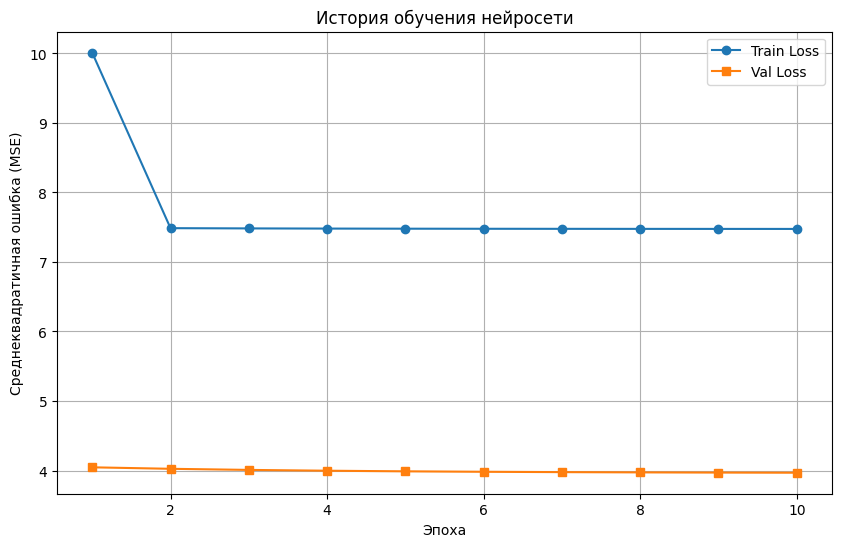

In [74]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), history_train, label='Train Loss', marker='o')
plt.plot(range(1, 11), history_val, label='Val Loss', marker='s')
plt.title('История обучения нейросети')
plt.xlabel('Эпоха')
plt.ylabel('Среднеквадратичная ошибка (MSE)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
'''
val loss (4.0), а train loss (7.5)

набор валидации оказался удачным, так как датсет маленький
train loss считаеся в процессе обучения, а val loss в конце эпохи
'''

**Задание 4**. Исследуйте влияние значения `leaning_rate` при обучении данной модели на данной задаче (не забудьте инициализировать модель для каждого нового значения `leaning_rate`). Постройте графики обучения на 10 эпохах при разном `leaning_rate`=[0.1, 0.01, 0.001, 0.0001]. На графиках покажите значения `train_loss` и `val_loss` при разных `leaning_rate`. Сделайте выводы.

Завершено обучение для LR=0.1. Итоговый Val Loss: nan
Завершено обучение для LR=0.01. Итоговый Val Loss: 3.9685
Завершено обучение для LR=0.001. Итоговый Val Loss: 2.6767
Завершено обучение для LR=0.0001. Итоговый Val Loss: 2.7684


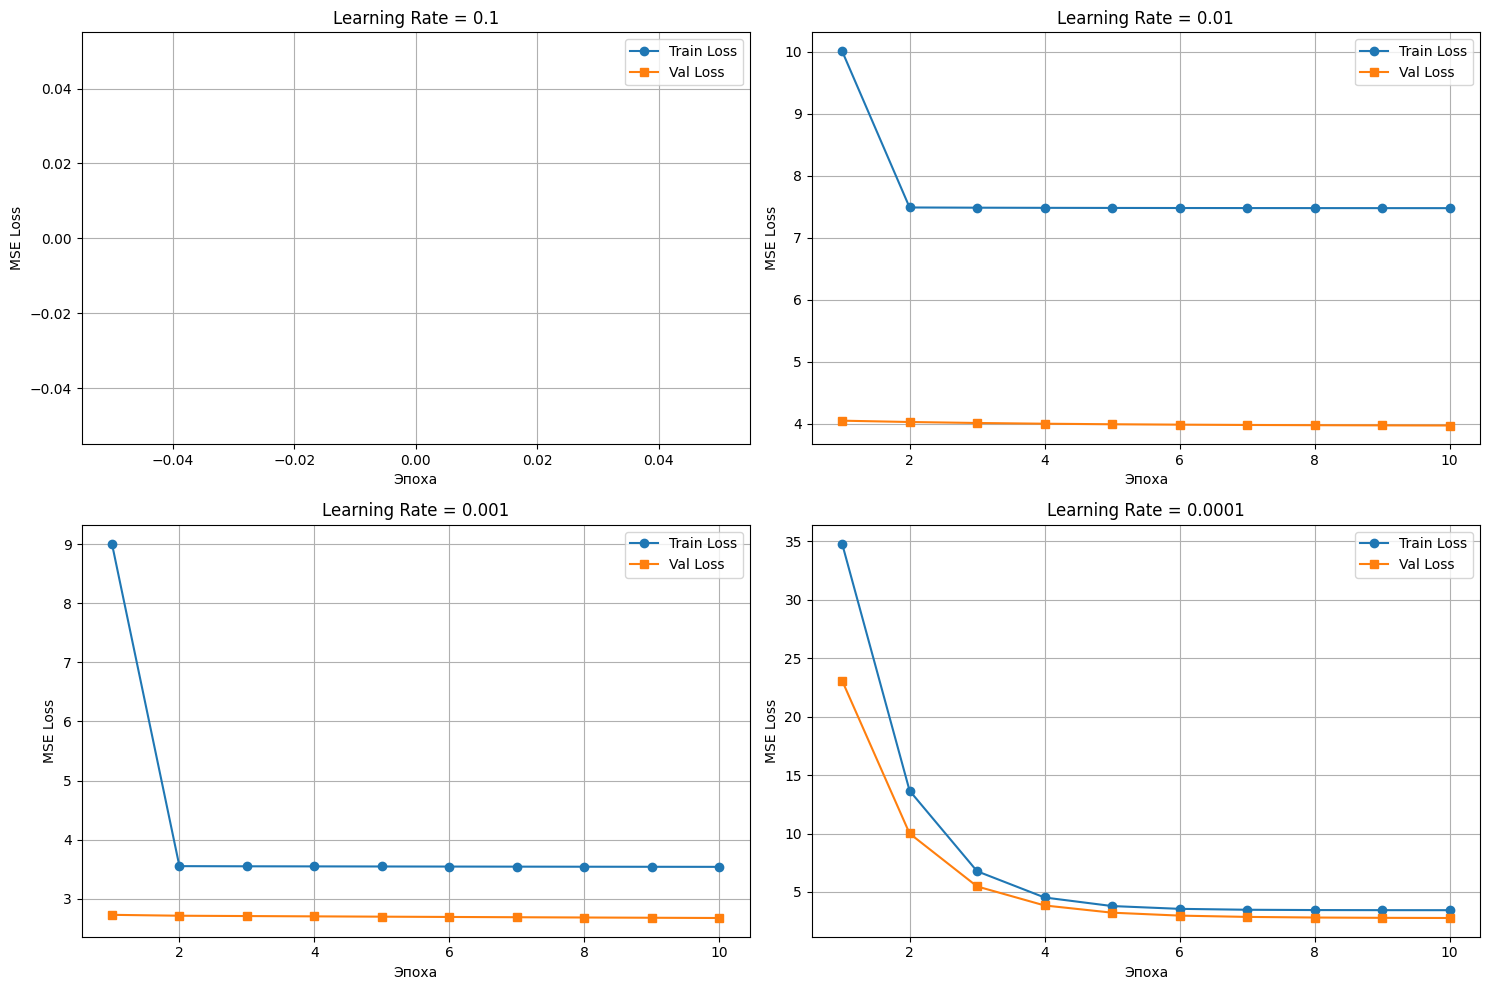

In [75]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    data.numpy(), targets.numpy(), test_size=0.2, random_state=42
)
X_train, X_val = torch.from_numpy(X_train), torch.from_numpy(X_val)
y_train, y_val = torch.from_numpy(y_train), torch.from_numpy(y_val)

lrs = [0.1, 0.01, 0.001, 0.0001]
epochs = 10
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

# Цикл по разным Learning Rate
for idx, lr in enumerate(lrs):
    torch.manual_seed(42) 
    model = NeuralNetwork()
    optimizer = optim.SGD(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    
    train_history = []
    val_history = []
    
    for epoch in range(epochs):
        # Обучение
        model.train()
        total_train_loss = 0
        for i in range(len(X_train)):
            optimizer.zero_grad()
            pred = model(X_train[i])
            loss = loss_fn(pred, y_train[i])
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()
        train_history.append(total_train_loss / len(X_train))
        
        # Валидация
        model.eval()
        total_val_loss = 0
        with torch.no_grad():
            for i in range(len(X_val)):
                v_pred = model(X_val[i])
                v_loss = loss_fn(v_pred, y_val[i])
                total_val_loss += v_loss.item()
        val_history.append(total_val_loss / len(X_val))

    # Визуализация для конкретного LR
    axes[idx].plot(range(1, epochs + 1), train_history, label='Train Loss', marker='o')
    axes[idx].plot(range(1, epochs + 1), val_history, label='Val Loss', marker='s')
    axes[idx].set_title(f'Learning Rate = {lr}')
    axes[idx].set_xlabel('Эпоха')
    axes[idx].set_ylabel('MSE Loss')
    axes[idx].legend()
    axes[idx].grid(True)
    print(f"Завершено обучение для LR={lr}. Итоговый Val Loss: {val_history[-1]:.4f}")

plt.tight_layout()
plt.show()

In [ ]:
'''
первый шаг слишком велик, потому произошёл "взрыв градиентов"
веса стали слишком большими числами, потому отображается как nan

 Наилучшие результаты показало значение LR = 0.001. 
 Оно обеспечивает самую низкую ошибку на валидации и стабильное,
 плавное снижение потерь без резких скачков.

 Низкие значения (0.0001) делают обучение слишком медленным, 
 требуя большего количества эпох, в то время как высокие значения (0.01)
могут приводить к «застреванию» на более высоких значениях ошибки
из-за чрезмерно больших шагов.
'''

'\n\n'

## Линейная классификация в PyTorch

#### Генерация набора данных
Сгенерируем набор данных для классификации: объекты с меткой "0" будут нормально распределены вокруг точки (-1, -1),  объекты с меткой "1" – вокруг точки (1, 1):

In [77]:
n_samples = 100
half = int(n_samples / 2)

x_class0 = np.random.normal(size=[half, 2]) + [-1, -1]
y_class0 = np.zeros((half, 1))

x_class1 = np.random.normal(size=[half, 2]) + [1, 1] #добавляем разброс
y_class1 = np.ones((half, 1))

data = np.vstack([x_class0, x_class1]) #смешиваем группы в один большой список
targets = np.vstack([y_class0, y_class1])

In [78]:
data = data.astype(np.float32)
targets = targets.astype(np.float32)

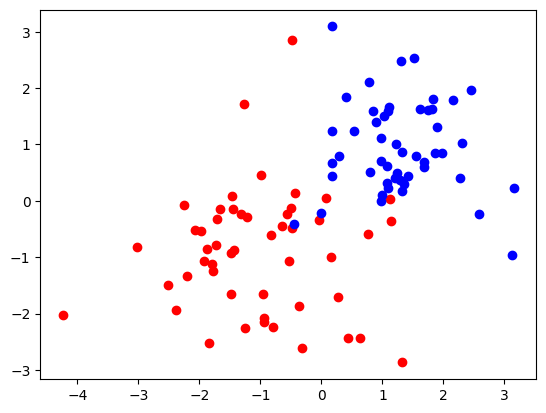

In [79]:
plt.scatter(x_class0[:, 0], x_class0[:, 1], c='red')
plt.scatter(x_class1[:, 0], x_class1[:, 1], c='blue')

**Задание 5.** Постройте нейронную сеть – линейный классификатор, разбейте набор данных на обучающую и валидацинную выборки. Визуализируйте полученные выборки данных.\
Обучите нейронную сеть на 20 эпохах. Визуализируйте обучение - построив график  знаечний `train_loss`, `val_loss` и `val_accuracy` на каждой эпохе. В качестве функции потерь можно использовать Binary Cross Entropy ([BCELOSS](https://pytorch.org/docs/stable/generated/torch.nn.BCELoss.html)).


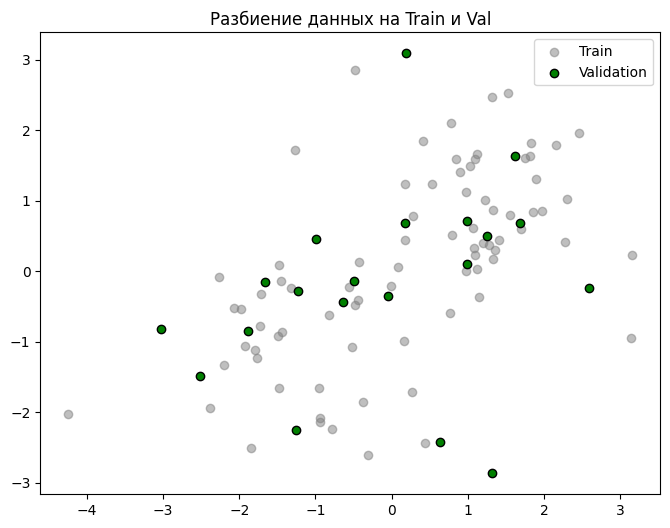

In [80]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# 1. Превращаем данные в тензоры
X = torch.from_numpy(data)
y = torch.from_numpy(targets)

# 2. Разбиваем на Train/Val (80/20)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Визуализация разделения
plt.figure(figsize=(8, 6))
plt.scatter(X_train[:, 0], X_train[:, 1], c='gray', alpha=0.5, label='Train')
plt.scatter(X_val[:, 0], X_val[:, 1], c='green', edgecolors='black', label='Validation')
plt.title("Разбиение данных на Train и Val")
plt.legend()
plt.show()

In [81]:
# Линейный классификатор
class LinearClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.regr = nn.Linear(2, 1) # 2 входа (x, y), 1 выход
        self.sigmoid = nn.Sigmoid() # Сжимаем в [0, 1]

    def forward(self, x):
        return self.sigmoid(self.regr(x))

# Функция для расчета точности (Accuracy)
def get_accuracy(y_pred, y_true):
    # Если вероятность > 0.5, то это класс 1, иначе класс 0
    predictions = (y_pred > 0.5).float()
    correct = (predictions == y_true).float().sum()
    return correct / len(y_true)

In [82]:
torch.manual_seed(42)
model = LinearClassifier()
optimizer = optim.SGD(model.parameters(), lr=0.1)
loss_fn = nn.BCELoss()

train_losses, val_losses, val_accuracies = [], [], []

for epoch in range(20):
    # Обучение
    model.train()
    optimizer.zero_grad()
    y_pred_train = model(X_train)
    loss = loss_fn(y_pred_train, y_train)
    loss.backward()
    optimizer.step()
    
    train_losses.append(loss.item())
    
    # Валидация
    model.eval()
    with torch.no_grad():
        y_pred_val = model(X_val)
        v_loss = loss_fn(y_pred_val, y_val)
        acc = get_accuracy(y_pred_val, y_val)
        
        val_losses.append(v_loss.item())
        val_accuracies.append(acc.item())
        
    if epoch % 2 == 0:
        print(f"Epoch {epoch}: Loss: {loss.item():.4f}, Val Acc: {acc.item():.4f}")

Epoch 0: Loss: 0.3261, Val Acc: 1.0000
Epoch 2: Loss: 0.3135, Val Acc: 1.0000
Epoch 4: Loss: 0.3027, Val Acc: 1.0000
Epoch 6: Loss: 0.2934, Val Acc: 1.0000
Epoch 8: Loss: 0.2853, Val Acc: 1.0000
Epoch 10: Loss: 0.2782, Val Acc: 1.0000
Epoch 12: Loss: 0.2719, Val Acc: 1.0000
Epoch 14: Loss: 0.2664, Val Acc: 1.0000
Epoch 16: Loss: 0.2614, Val Acc: 1.0000
Epoch 18: Loss: 0.2569, Val Acc: 1.0000


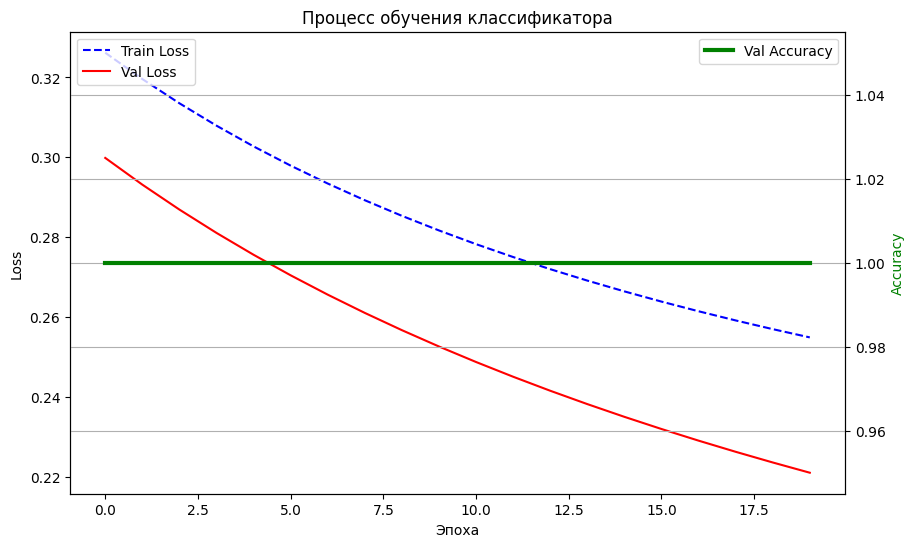

In [83]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Рисуем ошибки на левой оси Y
ax1.plot(train_losses, label='Train Loss', color='blue', linestyle='--')
ax1.plot(val_losses, label='Val Loss', color='red')
ax1.set_xlabel('Эпоха')
ax1.set_ylabel('Loss', color='black')
ax1.legend(loc='upper left')

# Создаем вторую ось Y для точности
ax2 = ax1.twinx()
ax2.plot(val_accuracies, label='Val Accuracy', color='green', linewidth=3)
ax2.set_ylabel('Accuracy', color='green')
ax2.legend(loc='upper right')

plt.title("Процесс обучения классификатора")
plt.grid(True)
plt.show()

In [ ]:
'''
функция потерь измеряет насколько модель оказалсь уверена в своем ответе

Валидационный лосс даже чуть ниже тренировочного — это говорит о том,
 что выборка для валидации оказалась очень «показательной» и легкой для модели.

значение функции потерь снизилось на ~25% (с 0.32 до 0.25), 
что сделало предсказания модели более уверенными.
'''